# Dataset Exploration & Visualization

This notebook loads three CSV datasets and uses **pandas**, **scikit-learn**, and **matplotlib** to summarize structure, spot missing values, and visualize distributions and relationships.

| Dataset | File | Rows (approx.) | Focus |
|---------|------|----------------|-------|
| Student performance | `student_performance.csv` | ~1,000 | Grades, study habits, demographics |
| Disease prediction | `disease_prediction.csv` | ~1,000 | Vitals, lifestyle, disease label |
| Movie database | `mymoviedb.csv` | ~9,800 | Ratings, popularity, genres, release dates |

In [11]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore")
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

DATA_DIR = Path(".")
STUDENT_PATH = DATA_DIR / "student_performance.csv"
DISEASE_PATH = DATA_DIR / "disease_prediction.csv"
MOVIE_PATH = DATA_DIR / "mymoviedb.csv"


def show_df_info(name: str, df: pd.DataFrame) -> None:
    print(f"\n{'=' * 60}\n{name}\n{'=' * 60}")
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"\nColumn dtypes:\n{df.dtypes}")
    missing = df.isna().sum()
    if missing.any():
        print(f"\nMissing values:\n{missing[missing > 0]}")
    else:
        print("\nNo missing values.")
    print(f"\nFirst 3 rows:\n{df.head(3).to_string()}")

In [16]:
students = pd.read_csv(STUDENT_PATH)
disease = pd.read_csv(DISEASE_PATH)
# Python engine handles long quoted Overview fields (C parser can overflow)
movies = pd.read_csv(MOVIE_PATH, engine="python", on_bad_lines="warn")

show_df_info("Student Performance", students)
show_df_info("Disease Prediction", disease)
show_df_info("Movie Database", movies)


Student Performance
Shape: 1,000 rows × 21 columns

Column dtypes:
Name                              str
Age                             int64
Gender                            str
Major                             str
Living_Area                       str
Parent_Education                  str
Scholarship_Status                str
Part_Time_Job                     str
Extracurricular_Activities        str
Internet_Access                   str
Study_Hours_Per_Day           float64
Sleep_Hours_Per_Day           float64
Attendance_Rate               float64
Stress_Level                  float64
Exam_Proximity                    str
Math_Score                      int64
Science_Score                   int64
Language_Score                  int64
History_Score                   int64
Average_Score                   int64
Grade                             str
dtype: object

No missing values.

First 3 rows:
               Name  Age  Gender Major Living_Area Parent_Education Scholarship_Statu

## 1. Student Performance

Academic scores, study/sleep hours, attendance, stress, and demographic factors. Target-like column: **Grade** (letter grades).

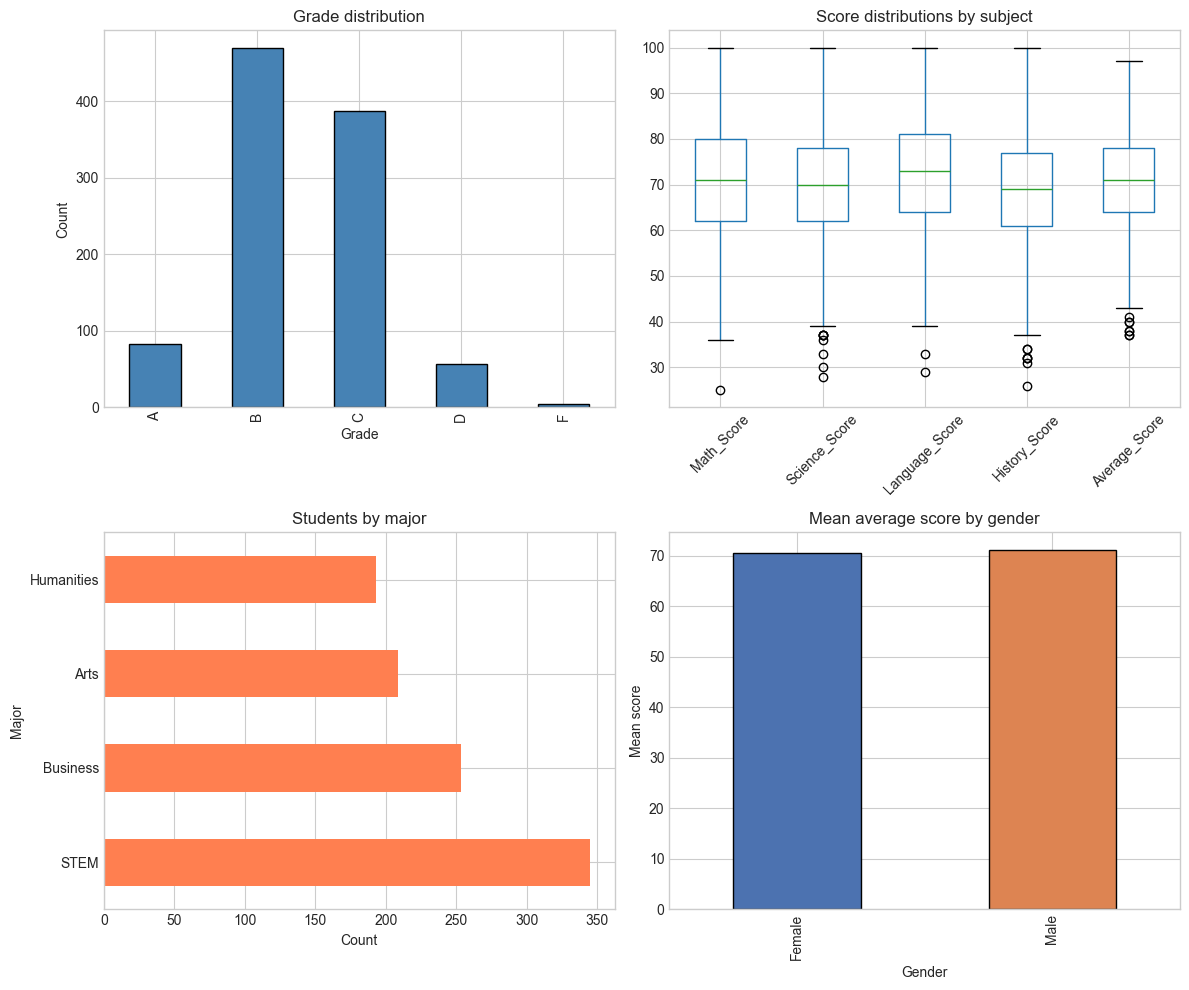

In [15]:
score_cols = ["Math_Score", "Science_Score", "Language_Score", "History_Score", "Average_Score"]
habit_cols = ["Study_Hours_Per_Day", "Sleep_Hours_Per_Day", "Attendance_Rate", "Stress_Level"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

grade_order = sorted(students["Grade"].unique(), key=lambda g: "ABCDEF".find(g) if g in "ABCDEF" else 99)
students["Grade"].value_counts().reindex(grade_order).plot(
    kind="bar", ax=axes[0, 0], color="steelblue", edgecolor="black"
)
axes[0, 0].set_title("Grade distribution")
axes[0, 0].set_xlabel("Grade")
axes[0, 0].set_ylabel("Count")

students[score_cols].boxplot(ax=axes[0, 1])
axes[0, 1].set_title("Score distributions by subject")
axes[0, 1].tick_params(axis="x", rotation=45)

students["Major"].value_counts().plot(kind="barh", ax=axes[1, 0], color="coral")
axes[1, 0].set_title("Students by major")
axes[1, 0].set_xlabel("Count")

students.groupby("Gender")["Average_Score"].mean().plot(
    kind="bar", ax=axes[1, 1], color=["#4C72B0", "#DD8452"], edgecolor="black"
)
axes[1, 1].set_title("Mean average score by gender")
axes[1, 1].set_ylabel("Mean score")

plt.tight_layout()
plt.show()

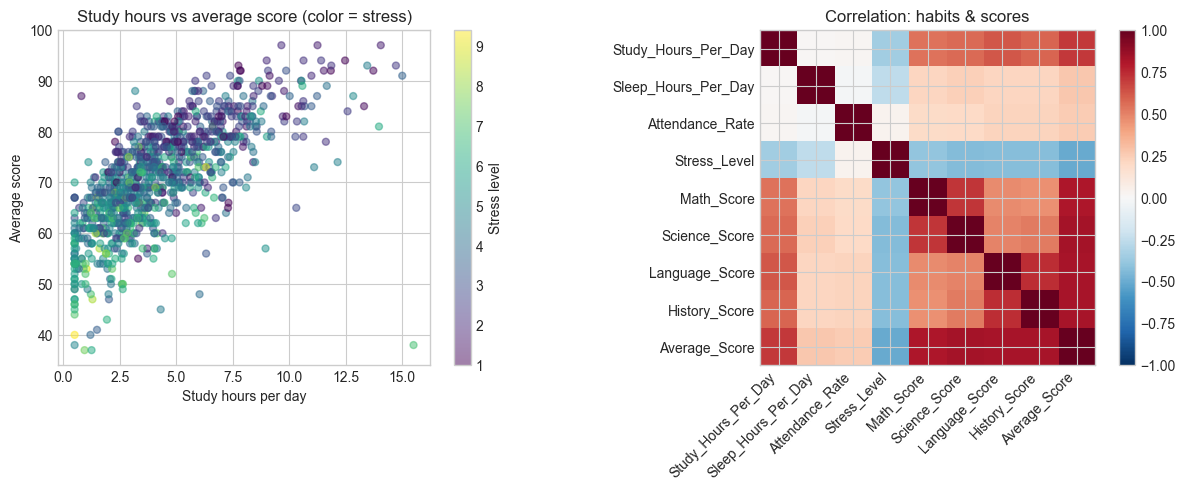

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc_study = axes[0].scatter(
    students["Study_Hours_Per_Day"],
    students["Average_Score"],
    alpha=0.5,
    c=students["Stress_Level"],
    cmap="viridis",
    s=25,
)
axes[0].set_xlabel("Study hours per day")
axes[0].set_ylabel("Average score")
axes[0].set_title("Study hours vs average score (color = stress)")
cbar = plt.colorbar(sc_study, ax=axes[0])
cbar.set_label("Stress level")

numeric_students = students[habit_cols + score_cols]
corr = numeric_students.corr()
im = axes[1].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr.columns)))
axes[1].set_yticks(range(len(corr.columns)))
axes[1].set_xticklabels(corr.columns, rotation=45, ha="right")
axes[1].set_yticklabels(corr.columns)
axes[1].set_title("Correlation: habits & scores")
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

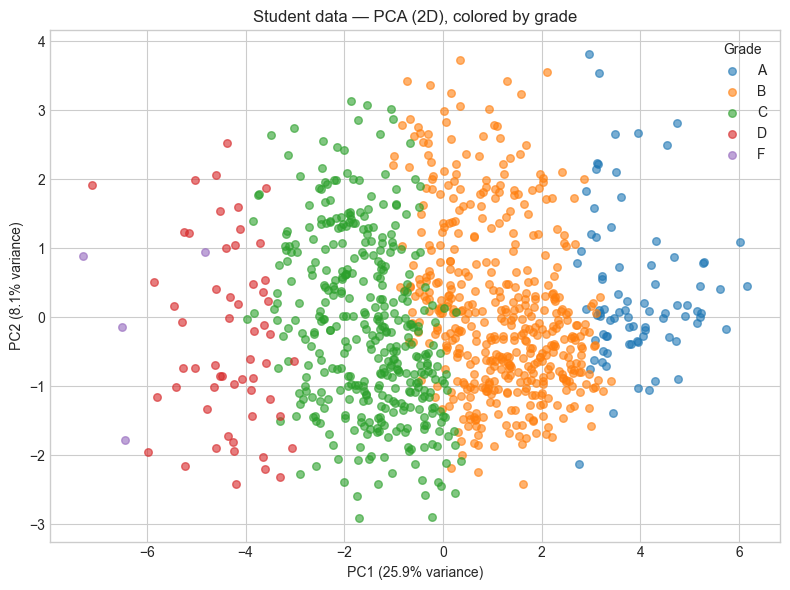

In [19]:
le = LabelEncoder()
students_encoded = students.copy()
cat_cols = students.select_dtypes(include="object").columns.drop("Name", errors="ignore")
for col in cat_cols:
    students_encoded[col] = le.fit_transform(students[col].astype(str))

feature_cols = [c for c in students_encoded.columns if c not in ("Name", "Grade")]
X = students_encoded[feature_cols].select_dtypes(include=np.number)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
grade_labels = students["Grade"].values

fig, ax = plt.subplots(figsize=(8, 6))
for grade in sorted(np.unique(grade_labels)):
    mask = grade_labels == grade
    ax.scatter(coords[mask, 0], coords[mask, 1], label=grade, alpha=0.6, s=30)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Student data — PCA (2D), colored by grade")
ax.legend(title="Grade", loc="best")
plt.tight_layout()
plt.show()

## 2. Disease Prediction

Clinical and lifestyle features with binary target **disease** (Yes/No).

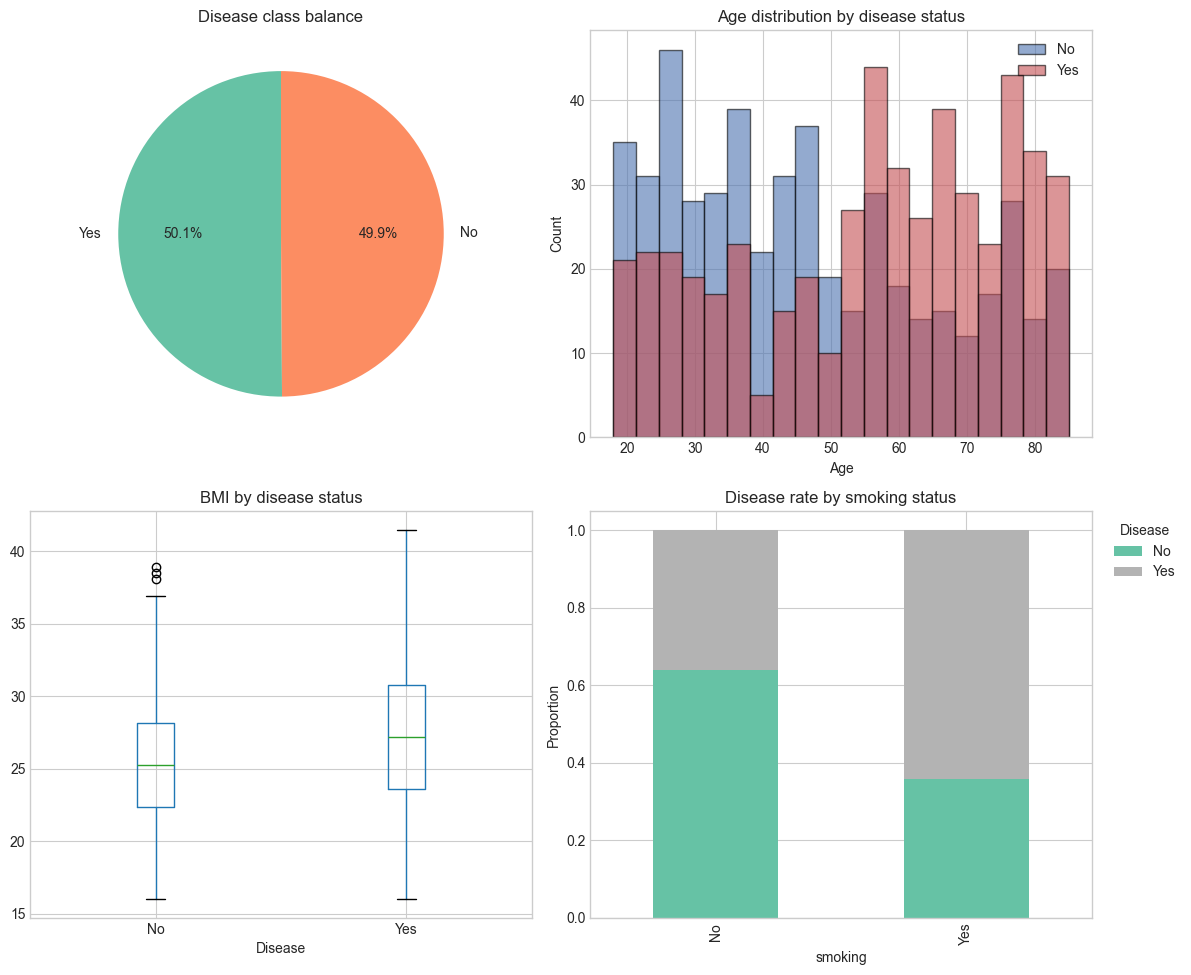

In [20]:
disease["disease_binary"] = (disease["disease"] == "Yes").astype(int)
vitals = ["age", "glucose_mg_dl", "cholesterol_mg_dl", "systolic_bp", "diastolic_bp", "bmi", "heart_rate"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

disease["disease"].value_counts().plot(
    kind="pie", ax=axes[0, 0], autopct="%1.1f%%", colors=["#66c2a5", "#fc8d62"], startangle=90
)
axes[0, 0].set_title("Disease class balance")
axes[0, 0].set_ylabel("")

for label, color in [("No", "#4C72B0"), ("Yes", "#C44E52")]:
    subset = disease.loc[disease["disease"] == label, "age"]
    axes[0, 1].hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor="black")
axes[0, 1].set_xlabel("Age")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Age distribution by disease status")
axes[0, 1].legend()

disease.boxplot(column="bmi", by="disease", ax=axes[1, 0])
axes[1, 0].set_title("BMI by disease status")
axes[1, 0].set_xlabel("Disease")
plt.suptitle("")

pd.crosstab(disease["smoking"], disease["disease"], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[1, 1], colormap="Set2"
)
axes[1, 1].set_title("Disease rate by smoking status")
axes[1, 1].set_ylabel("Proportion")
axes[1, 1].legend(title="Disease", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disease_encoded = disease.copy()
for col in disease.select_dtypes(include="object").columns:
    disease_encoded[col] = LabelEncoder().fit_transform(disease[col].astype(str))

X_d = disease_encoded[vitals + ["disease_binary"]].drop(columns=["disease_binary"])
corr_d = X_d.corr()
im = axes[0].imshow(corr_d, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr_d.columns)))
axes[0].set_yticks(range(len(corr_d.columns)))
axes[0].set_xticklabels(corr_d.columns, rotation=45, ha="right")
axes[0].set_yticklabels(corr_d.columns)
axes[0].set_title("Vital signs correlation matrix")
plt.colorbar(im, ax=axes[0], fraction=0.046)

means = disease.groupby("disease")[vitals].mean().T
x = np.arange(len(vitals))
width = 0.35
axes[1].bar(x - width / 2, means["No"], width, label="No disease", color="#4C72B0")
axes[1].bar(x + width / 2, means["Yes"], width, label="Yes disease", color="#C44E52")
axes[1].set_xticks(x)
axes[1].set_xticklabels(vitals, rotation=45, ha="right")
axes[1].set_title("Mean vitals: disease vs no disease")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
lifestyle_cols = ["smoking", "alcohol_consumption", "physical_activity", "family_history"]
lifestyle_rates = []
for col in lifestyle_cols:
    rate = disease.groupby(col)["disease_binary"].mean()
    lifestyle_rates.append(rate)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()
for ax, col, rates in zip(axes, lifestyle_cols, lifestyle_rates):
    rates.plot(kind="bar", ax=ax, color="teal", edgecolor="black")
    ax.set_title(f"Disease rate by {col}")
    ax.set_ylabel("P(disease = Yes)")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 3. Movie Database (TMDB-style)

Release dates, popularity, vote counts/averages, language, and multi-label genres.

In [ ]:
movies["Release_Date"] = pd.to_datetime(movies["Release_Date"], errors="coerce")
movies["Release_Year"] = movies["Release_Date"].dt.year

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

movies["Vote_Average"].hist(bins=30, ax=axes[0, 0], color="mediumpurple", edgecolor="black")
axes[0, 0].set_xlabel("Vote average")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of vote averages")

sample = movies.sample(min(2000, len(movies)), random_state=42)
axes[0, 1].scatter(sample["Popularity"], sample["Vote_Average"], alpha=0.35, s=15, c="darkorange")
axes[0, 1].set_xlabel("Popularity")
axes[0, 1].set_ylabel("Vote average")
axes[0, 1].set_title("Popularity vs vote average (sample)")

year_counts = movies["Release_Year"].dropna().astype(int).value_counts().sort_index()
year_counts.plot(kind="line", ax=axes[1, 0], color="green", linewidth=1.5)
axes[1, 0].set_xlabel("Release year")
axes[1, 0].set_ylabel("Number of movies")
axes[1, 0].set_title("Movies per release year")

movies["Original_Language"].value_counts().head(10).plot(
    kind="barh", ax=axes[1, 1], color="slategray"
)
axes[1, 1].set_title("Top 10 original languages")
axes[1, 1].set_xlabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
all_genres = (
    movies["Genre"]
    .dropna()
    .str.split(", ")
    .explode()
    .str.strip()
)
top_genres = all_genres.value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top_genres.plot(kind="barh", ax=axes[0], color="indianred")
axes[0].set_title("Top 12 genres (split multi-genre field)")
axes[0].set_xlabel("Appearances in dataset")
axes[0].invert_yaxis()

movies["Vote_Count"].apply(np.log1p).hist(bins=40, ax=axes[1], color="cadetblue", edgecolor="black")
axes[1].set_xlabel("log(1 + vote count)")
axes[1].set_ylabel("Count")
axes[1].set_title("Vote count distribution (log scale)")

plt.tight_layout()
plt.show()

In [ ]:
movie_numeric = movies[["Popularity", "Vote_Count", "Vote_Average"]].dropna()
X_m = StandardScaler().fit_transform(movie_numeric)
pca_m = PCA(n_components=2)
coords_m = pca_m.fit_transform(X_m)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    coords_m[:, 0],
    coords_m[:, 1],
    c=movie_numeric["Vote_Average"],
    cmap="plasma",
    alpha=0.5,
    s=12,
)
ax.set_xlabel(f"PC1 ({pca_m.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_m.explained_variance_ratio_[1]:.1%})")
ax.set_title("Movies — PCA on popularity, votes, rating")
plt.colorbar(sc, ax=ax, label="Vote average")
plt.tight_layout()
plt.show()

## Summary

- **Students**: Letter grades, subject scores, and study/attendance habits; PCA shows partial separation by grade.
- **Disease**: Binary outcome with vitals and lifestyle factors; compare class balance before modeling.
- **Movies**: Heavy-tailed popularity/vote counts; genres are comma-separated; use log transforms for skewed features.

Run all cells top-to-bottom. Ensure `pandas`, `matplotlib`, and `scikit-learn` are installed (`pip install pandas matplotlib scikit-learn`).